In [1]:
!unzip PySESM.zip
!pip install torchmetrics
!mkdir figs_1
!mkdir figs_2
!mkdir figs_3
!mkdir figs_4

Archive:  PySESM.zip
  inflating: PySESM/__init__.py      
   creating: PySESM/base_functions/
 extracting: PySESM/base_functions/__init__.py  
  inflating: PySESM/base_functions/Function.py  
   creating: PySESM/models/
 extracting: PySESM/models/__init__.py  
  inflating: PySESM/models/DictLayer.py  
  inflating: PySESM/models/ISTALayer.py  
   creating: PySESM/models/SESM/
 extracting: PySESM/models/SESM/__init__.py  
  inflating: PySESM/models/SESM/SESM.py  
   creating: PySESM/utils/
 extracting: PySESM/utils/__init__.py  
  inflating: PySESM/utils/linalg.py  
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.2/805.2 kB 8.8 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
from torchmetrics import MeanSquaredError, Accuracy, Precision, Recall, F1Score
from sklearn.model_selection import RandomizedSearchCV

from PySESM.models.SESM.SESM import SESM_Model
from PySESM.base_functions.Function import GaussianFunctions


## Definicion de covarianzas no diagnonales

In [3]:

# Non-diagonal covariance
def generate_sigma_tensors():
    e0 = torch.tensor([1.0, 1.0], dtype=torch.float32)
    e0 = e0 / e0.norm()

    def generate_sigma(rotation_angle, scaling_factors):
        rotation_matrix = torch.tensor([[np.cos(rotation_angle), -np.sin(rotation_angle)],
                                       [np.sin(rotation_angle), np.cos(rotation_angle)]], dtype=torch.float32)
        e = torch.mm(rotation_matrix, e0.unsqueeze(1))
        E = torch.cat((e0.unsqueeze(1), e), dim=1)
        D = torch.diag(torch.tensor(scaling_factors, dtype=torch.float32))
        return torch.mm(torch.mm(E, D), E.t())

    sigma1 = generate_sigma(np.pi/4, [0.4, 0.1])
    sigma2 = generate_sigma(np.pi/4, [0.05, 0.5])
    sigma3 = generate_sigma(np.pi/4, [0.2, 0.5])

    return sigma1, sigma2, sigma3


In [4]:
sigma1, sigma2, sigma3 = generate_sigma_tensors()

## Definicion de varianzas diagonales

In [5]:
sigma1_d = 0.15 * torch.eye(2)
sigma2_d = 0.2 * torch.eye(2)
sigma3_d = 0.3 *torch.eye(2)

## Crear Gaussianas

In [6]:
def custom_initializer(mean, std_dev, shape, a=0, b=1):
    # Crea una distribución gaussiana con los valores de media y desviación estándar
    distribution = torch.normal(mean=torch.full(shape, mean, dtype=torch.float32), std=torch.full(shape, std_dev, dtype=torch.float32))
    print("Pre-escalamiento: ", distribution)

    # Normaliza los valores generados en el rango a, b
    min_val, max_val = torch.min(distribution), torch.max(distribution)
    scaled_distribution = a + (distribution - min_val) * (b - a) / (max_val - min_val)

    return scaled_distribution

mean = 0.0
std_dev = 0.1
a = -1
b = 1
shape = (2,)

In [7]:
def generate_mesh_and_z(sigma1, sigma2, sigma3):
    N_points = 50
    xl = -2
    xr = 2

    x = np.linspace(xl, xr, N_points+1)
    xx, yy = np.meshgrid(x, x)

    X = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float32)

    mu1 = custom_initializer(mean, std_dev, shape, a, b)
    mu2 = custom_initializer(mean, std_dev, shape, a, b)
    mu3 = custom_initializer(mean, std_dev, shape, a, b)

    '''mu1 = torch.tensor([1, 1], dtype=torch.float32)
    mu2 = torch.tensor([1, -1], dtype=torch.float32)
    mu3 = torch.tensor([-1, -1], dtype=torch.float32)'''

    print("Myus: ", mu1, mu2, mu3)

    z1 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu1.numpy(), sigma1.numpy()), dtype=torch.float32)
    z2 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu2.numpy(), sigma2.numpy()), dtype=torch.float32)
    z3 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu3.numpy(), sigma3.numpy()), dtype=torch.float32)

    zz = (z1 + z2 + z3).reshape(xx.shape)

    return xx, yy, zz




## Covarianza de gaussianas del experimento:
  - 3 Diagonales
  - 2 Diagonales, 1 no diagonal
  - 1 diagonal, 2 no diagonales
  - 3 no diagonales

In [8]:

def run_experiment(_x, _y, _z, m_epochs, dict_epochs, h_epochs,expe, iter, debug=True):
  x_values = _x.ravel()
  y_values = _y.ravel()
  z_values = _z.ravel()

  n_samples = 500 # pueden aumentarse
  n_features = 2
  l_functions =  10 # bajarlas a <10
  total_points = len(x_values)

  min_separation = 1 # se puede reducir

  selected_indexes = []
  #Generate a uniform sampling
  while len(selected_indexes) < n_samples:

      random_index = np.random.randint(total_points)

      if all(abs(random_index - existing_index) >= min_separation for existing_index in selected_indexes):
          selected_indexes.append(random_index)

  sampled_indices = selected_indexes

  sampled_x = torch.tensor(x_values[sampled_indices], dtype=torch.float32)
  sampled_y = torch.tensor(y_values[sampled_indices], dtype=torch.float32)

  X = torch.stack((sampled_x, sampled_y), dim=1)
  y = z_values[sampled_indices].clone().detach().to(dtype=torch.float32)

  gaussian_function = GaussianFunctions(n_features= n_features, n_functions = l_functions)
  model = SESM_Model(
    n_samples=n_samples,
    n_features=n_features,
    n_functions=l_functions,
    psi=gaussian_function.gaussian
    )

  model_epochs = m_epochs
  ista_epochs = h_epochs
  dictionary_epochs = dict_epochs

  # reajustar estos parametros
  ista_alpha = 0.0125
  ista_lambd = 0.001

  dictionary_alpha = 0.0125

  model.fit(
      X=X,
      y=y,
      model_epochs=model_epochs,
      ista_epochs=ista_epochs,
      ista_alpha=ista_alpha,
      ista_lambd=ista_lambd,
      dictionary_epochs=dictionary_epochs,
      dictionary_alpha=dictionary_alpha
      )


  x_tensor = torch.tensor(x_values)
  y_tensor = torch.tensor(y_values)
  XY = torch.cat((x_tensor.unsqueeze(1), y_tensor.unsqueeze(1)), dim=1)

  Z = model.predict(XY)

  time = model.time/60

  #Init MSE metric
  mse = MeanSquaredError()
  # Compute MSE
  mse(Z.clone().detach(), z_values)
  mse_value = mse.compute()

  print(f"Losses lenght: {len(model.dictionary_layer.losses)}")

  if debug:
    fig = plt.figure(figsize=(6, 6))

    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(x_values, y_values, z_values,c=z_values)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('Original Function')


    ax2 = fig.add_subplot(222, projection='3d')
    ax2.scatter(x_values, y_values, Z.clone().detach(), c=Z.clone().detach())
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title('Surrogate Model')
    ax2.set_zlim(0)


    #Show the plot
    fname = f"figs_{expe}/{iter}.png"
    plt.savefig(fname)
    #plt.show()
    plt.clf()

    plt.plot(model.losses)
    plt.ylabel('Loss')
    plt.xlabel('Iteration')
    fname = f"figs_{expe}/{iter}-loss.png"
    plt.savefig(fname)
    print(f"Current h {model.ista_layer.h}")
  return time, mse_value

In [9]:
import csv

def save_results(data, expe):
  # Calcular el promedio y la desviación estándar para time y mse
  times = [item[1] for item in data]
  mse_values = [item[2] for item in data]

  average_time = np.mean(times)
  std_time = np.std(times)
  average_mse = np.mean(mse_values)
  std_mse = np.std(mse_values)

  # Guardar los datos en un archivo CSV
  with open(f"resultados_{expe}.csv", mode="w", newline="") as file:
      writer = csv.writer(file)
      writer.writerow(["iter", "Tiempo (min)", "mse"])
      writer.writerows(data)
      writer.writerow(["Promedio", average_time, average_mse])
      writer.writerow(["Desviación Estándar", std_time, std_mse])


In [10]:
# 3 diag
xx, yy, zz = generate_mesh_and_z(sigma1_d, sigma2_d, sigma3_d)

# 2 diag, 1 no diag
xx_1, yy_1, zz_1 = generate_mesh_and_z(sigma1_d, sigma2_d, sigma3)

# 1 diag, 2 no diag
xx_2, yy_2, zz_2 = generate_mesh_and_z(sigma1_d, sigma2, sigma3)
# 3 no diag
xx_3, yy_3, zz_3 = generate_mesh_and_z(sigma1, sigma2, sigma3)

Pre-escalamiento:  tensor([0.0094, 0.0280])
Pre-escalamiento:  tensor([ 0.1048, -0.0100])
Pre-escalamiento:  tensor([ 0.1081, -0.1027])
Myus:  tensor([-1.,  1.]) tensor([ 1., -1.]) tensor([ 1., -1.])
Pre-escalamiento:  tensor([-0.0024, -0.0110])
Pre-escalamiento:  tensor([0.1888, 0.0070])
Pre-escalamiento:  tensor([0.0180, 0.0786])
Myus:  tensor([ 1., -1.]) tensor([ 1., -1.]) tensor([-1.,  1.])
Pre-escalamiento:  tensor([-0.0524, -0.1068])
Pre-escalamiento:  tensor([-0.0324, -0.0570])
Pre-escalamiento:  tensor([0.0783, 0.1588])
Myus:  tensor([ 1., -1.]) tensor([ 1., -1.]) tensor([-1.,  1.])
Pre-escalamiento:  tensor([-0.0866,  0.2166])
Pre-escalamiento:  tensor([ 0.1363, -0.1633])
Pre-escalamiento:  tensor([-0.0778,  0.1829])
Myus:  tensor([-1.,  1.]) tensor([ 1., -1.]) tensor([-1.,  1.])


In [11]:

fig = go.Figure(data=[go.Surface(z=zz_3.numpy(), x=xx_3, y=yy_3)])
fig.update_layout(scene=dict(aspectmode='data'))
fig.update_layout(scene=dict(camera=dict(eye=dict(x=2, y=2, z=1))))

fig.show()

In [12]:
from google.colab import files

N_iter        = 1
m_epochs      = 20
dict_epochs   = 60
h_epochs      = 100

# Nomenclatura de experimentos

<Set de hiperparámetros>. <Set de datos (conjunto de gaussianas)>.<Número de repetición del experimento>


## Set de Hiperparámetros
|  Hiperparámetro | Exp 1.x.x     | Exp 2.x.x     | Exp 3.x.x     |
|-----------------|---------------|---------------|---------------|
| n_samples       | 50            | 100           | 500           |
| n_features      | 2             | 2             | 2             |
| l_functions     | 20            | 6             | 10            |
| ista_alpha      | 0.06          | 0.0125        | 0.0125        |
| ista_lambd      | 0.005         | 0.001         | 0.001         |
| dictionary_alpha| 0.06          | 0.0125        | 0.0125        |
| m_epochs        | 25            | 500           | 300           |
| dict_epochs     | 800           | 20            | 60            |
| h_epochs        | 1000          | 50            | 100           |


### Set de datos

|     Set      | Exp 1.x.x     | Exp 2.x.x     | Exp 3.x.x     |
|-----------------|---------------|---------------|---------------|
| Gaussianas 1    | Exp 1.1.x     | Exp 2.1.x     | Exp 3.1.x     |
| Gaussianas 2    | Exp 1.2.x     | Exp 2.2.x     | Exp 3.2.x     |
| Gaussianas 3    | Exp 1.3.x     | Exp 2.3.x     | Exp 3.3.x     |
| Gaussianas 4    | Exp 1.4.x     | Exp 2.4.x     | Exp 3.4.x     |


Training model:   5%|▌         | 1/20 [00:00<00:06,  2.94it/s]

Epoch 1 Loss: 2.3975274562835693



Training model:  10%|█         | 2/20 [00:00<00:07,  2.50it/s]

Epoch 2 Loss: 0.45477262139320374



Training model:  15%|█▌        | 3/20 [00:01<00:06,  2.49it/s]

...

Training model:  95%|█████████▌| 19/20 [00:05<00:00,  4.14it/s]

Epoch 19 Loss: 0.02214192971587181



Training model: 100%|██████████| 20/20 [00:05<00:00,  3.75it/s]

Epoch 20 Loss: 0.0215207077562809

Losses lenght: 1200


Current h Parameter containing:
tensor([ 0.2250,  0.0585,  0.2258, -0.0853, -0.0403, -0.0485, -0.0785,  0.4496,
        -0.0526,  0.7037], requires_grad=True)


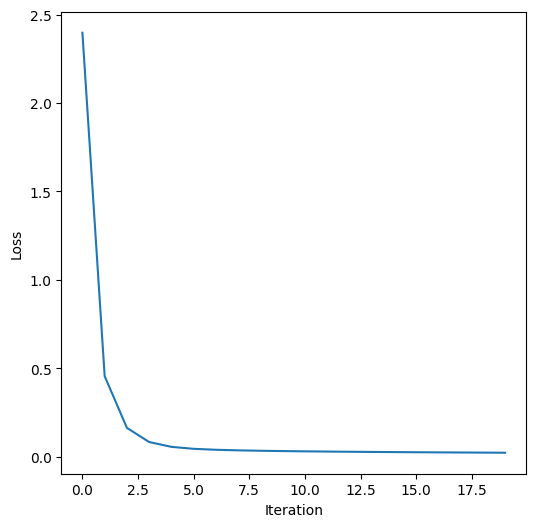

In [13]:

data = []
for i in range(N_iter):
  time, mse = run_experiment(xx,yy,zz,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=1, iter=i)
  data.append((i, time, mse.item()))

save_results(data=data, expe=1)

In [14]:
files.download('resultados_1.csv')
!zip -r figs_1.zip figs_1/
files.download('figs_1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_1/ (stored 0%)
  adding: figs_1/0.png (deflated 7%)
  adding: figs_1/0-loss.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training model:   5%|▌         | 1/20 [00:00<00:03,  5.25it/s]

Epoch 1 Loss: 2.1835310459136963



Training model:  10%|█         | 2/20 [00:00<00:04,  4.26it/s]

Epoch 2 Loss: 0.46706855297088623



Training model:  15%|█▌        | 3/20 [00:00<00:04,  4.19it/s]

...

Training model:  95%|█████████▌| 19/20 [00:04<00:00,  4.05it/s]

Epoch 19 Loss: 0.014240912161767483



Training model: 100%|██████████| 20/20 [00:04<00:00,  4.08it/s]

Epoch 20 Loss: 0.01370839960873127

Losses lenght: 1200


Current h Parameter containing:
tensor([-0.0873,  0.3205, -0.0641,  1.0903, -0.1644,  0.2525,  0.0552,  0.2944,
        -0.0315, -0.0286], requires_grad=True)


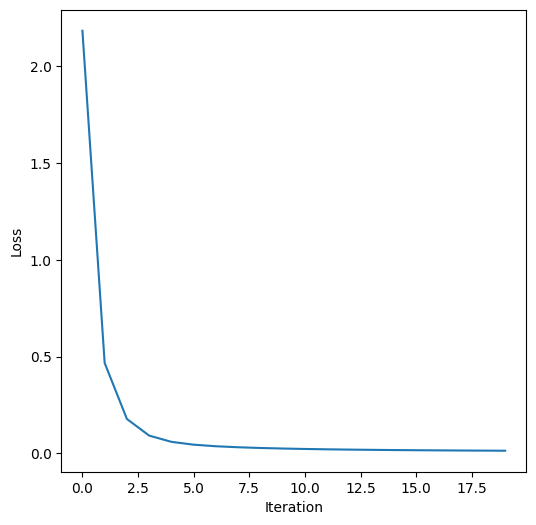

In [15]:
data_1 = []

for i in range(N_iter):
  time, mse = run_experiment(xx_1,yy_1,zz_1,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=2, iter=i)
  data_1.append((i, time, mse.item()))

save_results(data=data_1, expe=2)

In [16]:
files.download('resultados_2.csv')
!zip -r figs_2.zip figs_2/
files.download('figs_2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_2/ (stored 0%)
  adding: figs_2/0.png (deflated 7%)
  adding: figs_2/0-loss.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training model:   5%|▌         | 1/20 [00:00<00:09,  2.02it/s]

Epoch 1 Loss: 2.302834987640381



Training model:  10%|█         | 2/20 [00:01<00:11,  1.50it/s]

Epoch 2 Loss: 0.5063825845718384



Training model:  15%|█▌        | 3/20 [00:02<00:12,  1.33it/s]

...

Training model:  95%|█████████▌| 19/20 [00:09<00:00,  2.16it/s]

Epoch 19 Loss: 0.039030447602272034



Training model: 100%|██████████| 20/20 [00:10<00:00,  1.94it/s]

Epoch 20 Loss: 0.037982027977705

Losses lenght: 1200


Current h Parameter containing:
tensor([-0.1281,  0.0457,  0.0769,  0.1394,  0.0315, -0.1005,  0.9719,  0.0607,
         0.2771,  0.3325], requires_grad=True)


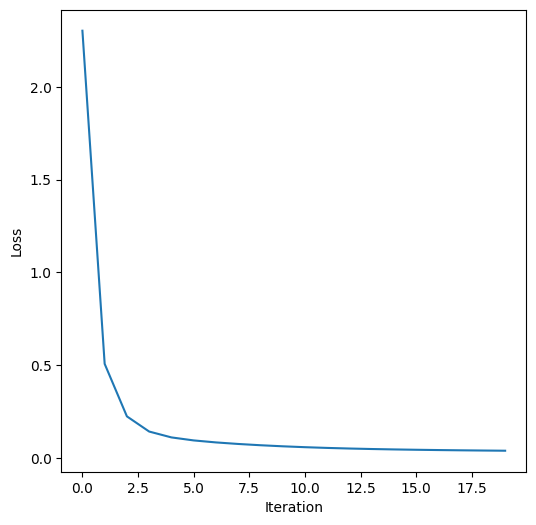

In [17]:
data_2 = []
for i in range(N_iter):
  time, mse = run_experiment(xx_2,yy_2,zz_2,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=3, iter=i)
  data_2.append((i, time, mse.item()))

save_results(data=data_2, expe=3)

In [18]:
files.download('resultados_3.csv')
!zip -r figs_3.zip figs_3/
files.download('figs_3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_3/ (stored 0%)
  adding: figs_3/0.png (deflated 7%)
  adding: figs_3/0-loss.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training model:   5%|▌         | 1/20 [00:00<00:06,  2.91it/s]

Epoch 1 Loss: 2.3390910625457764



Training model:  10%|█         | 2/20 [00:00<00:06,  2.80it/s]

Epoch 2 Loss: 0.4398708641529083



Training model:  15%|█▌        | 3/20 [00:01<00:06,  2.72it/s]

...

Training model:  95%|█████████▌| 19/20 [00:11<00:00,  2.25it/s]

Epoch 19 Loss: 0.036270804703235626



Training model: 100%|██████████| 20/20 [00:11<00:00,  1.75it/s]

Epoch 20 Loss: 0.03566545248031616

Losses lenght: 1200


Current h Parameter containing:
tensor([ 0.0148, -0.0525,  0.5295, -0.1073,  0.5316, -0.1726,  0.2953,  0.6251,
         0.0660,  0.0762], requires_grad=True)


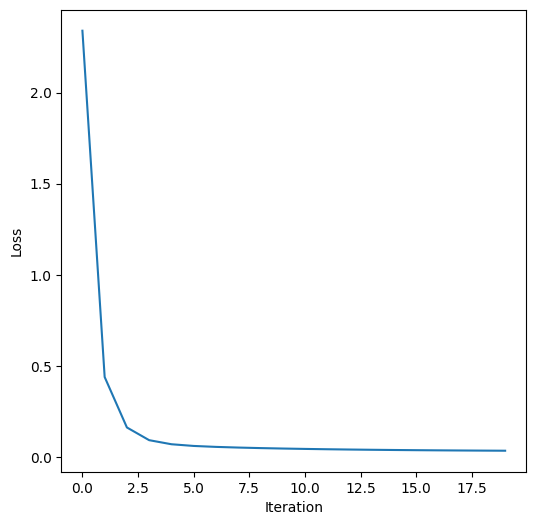

In [19]:
data_3 = []
for i in range(N_iter):
  time, mse = run_experiment(xx_3,yy_3,zz_3,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=4, iter=i)
  data_3.append((i, time, mse.item()))

save_results(data=data_3, expe=4)

In [20]:

files.download('resultados_4.csv')
!zip -r figs_4.zip figs_4/
files.download('figs_4.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_4/ (stored 0%)
  adding: figs_4/0.png (deflated 5%)
  adding: figs_4/0-loss.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>